# Basic Black and Scholes

## 1. Basic Premium Calculation

Computes the premium required to hedge against a commodity’s price increasing by more than P% from its current level at a future settlement date T.

I will use the Black and Scholes formula to calculate the price of a call option on the underlying asset (commodity). I will set the strike price of the call option to: 

$$ K = S_0 \times (1 + P\%) $$

Each call option represents 100 shares so we divide the volume of shares owned by 100 to find the number of options we need to purchase for our hedging strategy.

Because I am pricing the option using the Black and Scholes model I am using the following assumptions:
1. Commodity price follows a Geometric BM
1. No transaction costs
1. Securities are perfectly divisible
1. No arbitrage
1. Trading takes place in a continuous-time setting

The Black and Scholes solution gives:

$$
C = S_0N(d_1) - Ke^{-rT}N(d_2)
$$

With constants:

$$
d_1 = \frac{ln(\frac{S_0}{K}) + (\mu + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}
\newline
d_2 = d_1 - \sigma \sqrt{T}
$$

For $\mu$ we can use the risk-free interest rate, $r$.

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import yfinance as yf

from datetime import datetime
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt

In [4]:
def Black_Scholes_call(S_0, K, T, r, sigma):
    """
    Calculates the premium of the stock based on the Black and Scholes formula
    
    S_0: Commodity stock price now
    P: Percentage increase of commodity price
    T: Time to maturity of the call option
    r: Risk-free interest rate
    sigma: Volatility of the commodity stock price
    """
    
    d_1 = (np.log(S_0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d_2 = d_1 - sigma * np.sqrt(T)

    return S_0 * norm.cdf(d_1) - K * np.exp(-r * T) * norm.cdf(d_2)

The interest rate, $r$ can be approximated as the value of the 10-Year US Treasury Bond. Of course I can look it up also but since I am using yfinance I thought why not use this approximation.

The volatility is hard to estimate. Generally there are two ways of calculating the volatility of an asset:
1. Use historic data for the underlying (backwards-looking)
1. Calculate the volatility implied by prices of related derivatives (forward-looking)

For simplicity, I will use the Close price of the stock, $S_{c,t}$ and calculate the log returns. From the Black and Scholes formula, we know:

$$
\text{ln}(S_i) - \text{ln}(S_{i-1}) \sim N\left(\left(r - \frac{\sigma^2}{2}\right)t, \text{ }\sigma^2t\right)
$$

Therefore, we need to calculate the variance of the log returns. We can use the formula for the unbiased variance:

$$
s^2 = \frac{1}{n-1} \sum_{i=0}^n \left( x_i - \bar{x} \right)^2
$$

where $\bar{x}$ is the sample mean and is calculated as follows:

$$
\bar{x} = \frac{1}{n} \sum_{i=0}^n x_i 
$$

Finally we have:

$$
s^2 = \sigma^2t
\newline
\bar{x} = \left(\mu - \frac{\sigma^2}{2}\right)t = \mu t - \frac{s^2}{2}
$$

Solving we obtain:

$$
\sigma = \frac{s}{\sqrt{t}}
$$

$$
\mu = \frac{\bar{x}}{t} + \frac{s^2}{2t}
$$

In [5]:
def Treasury_Yield_10Y():
    """
    Calculates the Risk-free based on the 10Y US Treasury Yield Bond
    """

    treasury_yield = yf.Ticker("^TNX") # set the index to 10 Year Tresury Bond
    yield_data = treasury_yield.history(period="1d")
    r = yield_data["Close"].iloc[-1] / 100 # get spot price
    return r

def Get_Data(index_label, period, interval):
    """
    Calculates the security's spot price and historic close values

    index_label: label of the security at interest
    period: time period for historical data (e.g., "1y" for 1 year)
    interval: interval for historical data (e.g., "1d" for daily)
    """

    security = yf.Ticker(index_label)  # set index to security
    security_history = security.history(period=period, interval=interval)  # get historical data
    security_close = security_history['Close'].to_numpy()  # get close data
    security_spot_price = security_close[-1]  # get the spot price
    return security_spot_price, security_close

def Drift_Volatility(data, tau):
    """
    Calculates the annualized drift (mu) and volatility (sigma) of a security's returns

    data: array of historical closing prices of the security
    tau: time constant of sampling interval
    """
    
    log_returns = np.log(data[1:] / data[:-1]) # log returns

    x_bar = np.mean(log_returns)
    sample_var = np.var(log_returns, ddof=1)  # ddof = 1 for unbiased sample variance

    sigma = np.sqrt(sample_var) / np.sqrt(tau)  # annualize volatility
    mu = x_bar / tau + sample_var / 2 / tau # annualize drift
    return mu, sigma

def get_tau(time_interval):
    inter_to_tau = {
        '3mo': 1/4,
        '1mo': 1/12,
        '1wk': 1/52,
        '1d': 1/252,
        '1h': 1/(23 * 252)
    }
    return inter_to_tau[time_interval]

def print_analytics(interest_rate=None, spot_price=None, mu=None, sigma=None, premium=None):
    if interest_rate is not None:
        print("Risk-free rate (r):", round(interest_rate, 4))
    if spot_price is not None:
        print("Spot price: $", round(spot_price, 2))
    if mu is not None:
        print("Drift (mu):", round(mu, 3))
    if sigma is not None:
        print("Volatility (sigma):", round(sigma, 3))
    if premium is not None:
        print('Option Premium: $', round(premium, 2))

In [6]:
def premium_calculation(index_label, sample_interval, stats_show=True):
    # set some random values for these constants
    P = 0.2
    T = 1

    r = Treasury_Yield_10Y()
    security_spot_price, security_close = Get_Data(index_label=index_label, period='1y', interval=sample_interval)
    tau = get_tau(sample_interval)
    mu, sigma = Drift_Volatility(security_close, tau)
    K = security_spot_price * (1 + P) # calculate the strike price
    premium = Black_Scholes_call(security_spot_price, K, T, r, sigma)

    if stats_show:
        print_analytics(interest_rate=r, spot_price=security_spot_price, mu=mu, sigma=sigma, premium=premium)
    return premium, {'r':r, 'spot':security_spot_price, 'mu':mu, 'sigma':sigma}

In [7]:
_ = premium_calculation("GC=F", '1d')

Risk-free rate (r): 0.0433
Spot price: $ 3386.0
Drift (mu): 0.358
Volatility (sigma): 0.181
Option Premium: $ 82.87


## 2. Average Price Calculation

Modifies the function so that the payout triggers when the average price over the previous month exceeds the P% threshold, rather than just the most recent price.

To accomodate for this change, we simply need to set the strike price K to:
$$
K = \bar{S} \times (1 + P\%)
$$
where $\bar{S}$ is the average price over the previous month.

In [8]:
def Get_S_Bar(index_label):
    """
    Calculates the security's average price based on last month's close prices

    index_label: label of the security at interest
    """

    previous_month = datetime.now() - relativedelta(months=1)
    previous_month = previous_month.strftime("%Y-%m") # last month
    security = yf.Ticker(index_label)
    security_history = security.history(period="3mo", interval="1d")
    S_bar = security_history[security_history.index.strftime("%Y-%m") == previous_month]['Close'].mean() # get the average price of the last month based on the close values
    return S_bar

In [9]:
def premium_calculation_month_average(index_label, sample_interval, stats_show=True):
    # set some random values for these constants
    P = 0.2
    T = 1

    r = Treasury_Yield_10Y()
    security_spot_price, security_close = Get_Data(index_label=index_label, period='1y', interval=sample_interval)
    tau = get_tau(sample_interval)
    S_bar = Get_S_Bar(index_label) # get the average stock price of last month
    mu, sigma = Drift_Volatility(security_close, tau)
    K = S_bar * (1 + P) # calculate the strike price
    premium = Black_Scholes_call(security_spot_price, K, T, r, sigma)

    if stats_show:
        print("security last month average price: $", round(S_bar, 2))
        print_analytics(interest_rate=r, spot_price=security_spot_price, mu=mu, sigma=sigma, premium=premium)
    return premium, {'r':r, 'spot':security_spot_price, 'mu':mu, 'sigma':sigma}

In [10]:
_ = premium_calculation_month_average('GC=F', '1d')

security last month average price: $ 3350.94
Risk-free rate (r): 0.0433
Spot price: $ 3386.0
Drift (mu): 0.358
Volatility (sigma): 0.181
Option Premium: $ 91.05


## 3. Handling Price Spikes

Further adapt the function to account for commodities with sudden price spikes (e.g., electricity), ensuring the premium reflects this risk.

For European options, price spikes should not significantly impact the premium beyond what has already been factored into the pricing model. Using a sampling frequency of 1 hour can effectively demonstrate the influence of such spikes. As evident from the data, the volatility of electricity is notably higher compared to that of gold and silver and the estimate significanty increases then we increase the data sampling frequency.

In [11]:
freq_list = ['1wk', '1d', '1h']

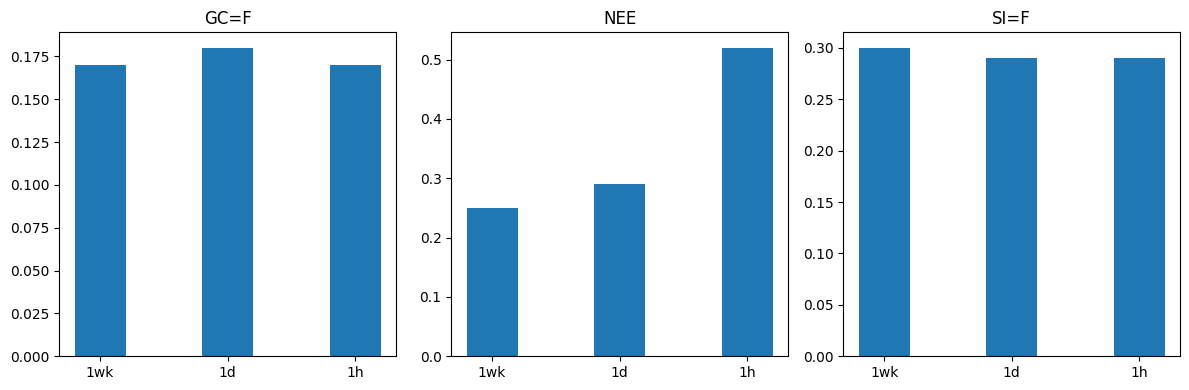

In [12]:
def plot(index_label, ax):
    vol_list = []
    # get the volatilities of the commodities
    for i in range(len(freq_list)):
        _, stats = premium_calculation(index_label, freq_list[i], stats_show=False)
        vol = round(stats['sigma'], 2)
        vol_list.append(vol)
    
    # plot the results using bar plots
    ax.bar(freq_list, vol_list, width=0.4)
    ax.set_title(index_label)


index_list = ['GC=F', 'NEE', 'SI=F']  # ~ gold, electricity, silver
fig, axes = plt.subplots(1, len(index_list), figsize=(12, 4))
for i, index_label in enumerate(index_list):
    plot(index_label, axes[i])
plt.tight_layout()
plt.show()